## Duration

Modified duration is the sensitivity of bond price on interest rate change.

In [1]:
import pandas as pd 

# Fitted Yield on Zero Coupon Bonds by Maturity
# https://fred.stlouisfed.org/release/tables?eid=212994&rid=354
df_zero_rate = pd.DataFrame([
{"Maturity":1, "2025-01-02":4.2491, "2025-12-31":3.5099},
{"Maturity":2, "2025-01-02":4.2433, "2025-12-31":3.4833},
{"Maturity":3, "2025-01-02":4.2425, "2025-12-31":3.5255},
{"Maturity":4, "2025-01-02":4.2582, "2025-12-31":3.6032},
{"Maturity":5, "2025-01-02":4.2917, "2025-12-31":3.6992},
{"Maturity":6, "2025-01-02":4.3405, "2025-12-31":3.8043},
{"Maturity":7, "2025-01-02":4.4010, "2025-12-31":3.9133},
{"Maturity":8, "2025-01-02":4.4701, "2025-12-31":4.0233},
{"Maturity":9, "2025-01-02":4.5450, "2025-12-31":4.1326},
{"Maturity":10,"2025-01-02":4.6235, "2025-12-31":4.2401},
]).set_index("Maturity")

In [2]:
import pandas as pd 
import numpy as np 
from scipy.optimize import fsolve

# Daily Treasury Par Yield Curve Rates
# df = pd.read_xml("https://home.treasury.gov/resource-center/data-chart-center/interest-rates/pages/xml?data=daily_treasury_yield_curve&field_tdr_date_value=2025")
df = pd.read_xml("x04_treasury_daily.xml", xpath=".//m:properties", namespaces={
    "m": "http://schemas.microsoft.com/ado/2007/08/dataservices/metadata",
    "d": "http://schemas.microsoft.com/ado/2007/08/dataservices",
    "atom": "http://www.w3.org/2005/Atom"
}).set_index("NEW_DATE")


# Bootstrap
m = 2
zero_rates = dict()


## 6mo bond
cf1 = 100 + df["BC_6MONTH"] / m
#dc1 = np.exp(-0.5 * zero_rates[0.5] 
pv = 100 # = cf1 * dc1
zero_rates[0.5] = np.log(pv / cf1) / (-0.5)

## 1yr bond
cf1 = df["BC_1YEAR"] / m
dc1 = np.exp(-0.5 * zero_rates[0.5])
cf2 = 100 + df["BC_1YEAR"] / m
#dc2 = np.exp(-1.0 * zero_rates[1.0])
pv = 100 # = cf1 * dc1 + cf2 * dc2
dc2 = ( pv - cf1 * dc1 ) / cf2
zero_rates[1.0] = np.log(dc2) / (-1.0)

## 2yr bond 
cf = df["BC_2YEAR"] / m
dc1 = np.exp(-0.5 * zero_rates[0.5])
dc2 = np.exp(-1.0 * zero_rates[1.0])
dc3 = lambda zr15 : np.exp(-1.5 * zr15)
dc4 = lambda zr20 : np.exp(-2.0 * zr20)
# warning : It's incorrect but let's assume that zero_rates[1.5] == zero_rates[2.0]
pv = 100 # = cf1 * dc1 + cf2 * dc2 + cf3 * dc3 + cf4 * dc4
zero_rates[2.0] = dict()
for i, _cf, _dc1, _dc2 in zip(cf.index, cf.values, dc1.values, dc2.values):
    zero_rates[2.0][i] = fsolve( lambda r : _cf * _dc1 + _cf * _dc2 + _cf * dc3(r) + (100+_cf) * dc4(r) - 100, 0)[0]
zero_rates[2.0] = pd.Series(zero_rates[2.0])
zero_rates[1.5] = zero_rates[2.0] # Backfill

## 3yr bond 
cf = df["BC_3YEAR"] / m
dc1 = np.exp(-0.5 * zero_rates[0.5])
dc2 = np.exp(-1.0 * zero_rates[1.0])
dc3 = np.exp(-1.5 * zero_rates[1.5])
dc4 = np.exp(-2.0 * zero_rates[2.0])
dc5 = lambda zr25 : np.exp(-2.5 * zr25)
dc6 = lambda zr30 : np.exp(-3.0 * zr30)
pv = 100
zero_rates[3.0] = dict()
for i, _cf, _dc1, _dc2, _dc3, _dc4 in zip(cf1.index, cf.values, dc1.values, dc2.values, dc3.values, dc4.values):
    zero_rates[3.0][i] = fsolve( lambda r : _cf * _dc1 + _cf * _dc2 + _cf * _dc3  + _cf * _dc4 + _cf * dc5(r) + (100+_cf) * dc6(r) - 100, 0)[0]
zero_rates[3.0] = pd.Series(zero_rates[3.0])
zero_rates[2.5] = zero_rates[3.0] # Backfill

In [3]:
df_zero_rates = pd.DataFrame(zero_rates).sort_index(axis=1)
df_zero_rates

,0.5,1.0,1.5,2.0,2.5,3.0
2025-01-02T00:00:00,0.042055,0.041263,0.042063,0.042063,0.042466,0.042466
2025-01-03T00:00:00,0.042055,0.041362,0.042361,0.042361,0.042763,0.042763
2025-01-06T00:00:00,0.041957,0.041264,0.042362,0.042362,0.042561,0.042561
2025-01-07T00:00:00,0.041957,0.041462,0.042559,0.042559,0.042859,0.042859
2025-01-08T00:00:00,0.042055,0.041461,0.042360,0.042360,0.042661,0.042661
...,...,...,...,...,...,...
2025-12-24T00:00:00,0.035582,0.034690,0.034395,0.034395,0.035308,0.035308
2025-12-26T00:00:00,0.035483,0.034591,0.034296,0.034296,0.035109,0.035109
2025-12-29T00:00:00,0.035582,0.034491,0.034197,0.034197,0.034807,0.034807
2025-12-30T00:00:00,0.035582,0.034392,0.034198,0.034198,0.034707,0.034707


Text(0.5, 1.0, 'Blue : Price of 3Y bond with 3% PA at the issue date,\neach calculated at the issue date\n\nRed : Interest Rate (Inverted)')

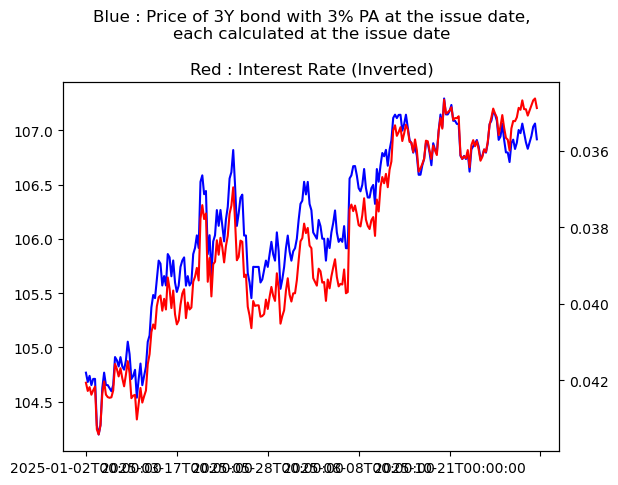

In [4]:
## Pricing of bond

# Maturity = 3Y
# Coupon Rate = 3.0% p.a.
# Principal = 100

from matplotlib import pyplot as plt
fig0, ax0 = plt.subplots()
ax1 = ax0.twinx()

df_bond_price = df_zero_rates.eval(
    "+".join([f"3 * exp(-{x} *`{x}`)" for x in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]])
    + "+ 100 * exp(-3.0 *`3.0`)"
    )
df_bond_price.plot(ax=ax0, color="Blue")

df_rate_avg = df_zero_rates.mean(axis=1)
df_rate_avg.plot(ax=ax1, color="Red")
ax1.yaxis.set_inverted(True)

plt.title("Blue : Price of 3Y bond with 3% PA at the issue date,\neach calculated at the issue date\n\nRed : Interest Rate (Inverted)")

<Axes: title={'center': 'Delta = -3.529935615942721'}, xlabel='YTD change of zero rate', ylabel='YTD bond price return'>

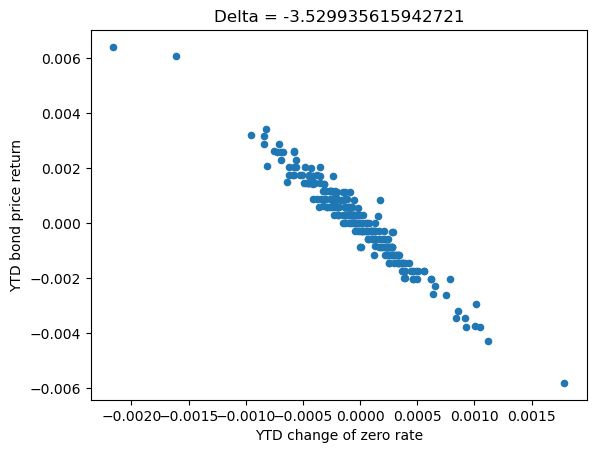

In [5]:
interest_rate_change = df_rate_avg.diff().iloc[1:]
bond_price_change_pct = df_bond_price.diff().iloc[1:]

delta, intercept = np.polyfit(interest_rate_change, 0.01 * bond_price_change_pct, 1)

pd.DataFrame({
    "YTD change of zero rate" : interest_rate_change,
    "YTD bond price return" : bond_price_change_pct * 0.01,
}).plot.scatter(x=0,y=1,title=f"Delta = {delta}")

### What if the change of zero rate was equal for all maturity?

That is pure uniform shift of zero rate

<Axes: title={'center': 'Delta = -2.9409735352837045'}, xlabel='YTD change of zero rate', ylabel='YTD bond price return'>

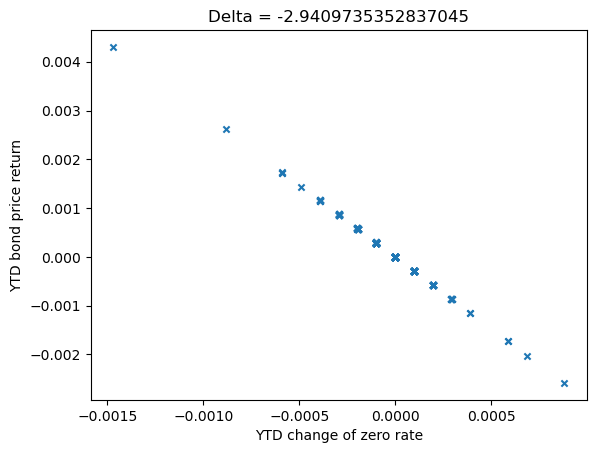

In [6]:
df_zero_rates = pd.DataFrame(zero_rates)
curve_shape = (df_zero_rates.iloc[0,:] - df_zero_rates.iloc[0,0])
# curve_shape = (df_zero_rates.iloc[0,:] / df_zero_rates.iloc[0,0])
shifts = df_zero_rates.iloc[:,0]

df_zero_rates_hypothetical = df_zero_rates.copy()
df_zero_rates_hypothetical.iloc[:,1:] = np.nan 
df_zero_rates_hypothetical = df_zero_rates_hypothetical.ffill(axis=1)
df_zero_rates_hypothetical += curve_shape
# df_zero_rates_hypothetical *= curve_shape

df_bond_price = df_zero_rates_hypothetical.eval(
    "+".join([f"3 * exp(-{x} *`{x}`)" for x in [0.5, 1.0, 1.5, 2.0, 2.5, 3.0]])
    + "+ 100 * exp(-3.0 *`3.0`)"
    )
df_rate_avg = df_zero_rates_hypothetical.mean(axis=1)
interest_rate_change = df_rate_avg.diff().iloc[1:]
bond_price_change_pct = df_bond_price.diff().iloc[1:]

delta, intercept = np.polyfit(interest_rate_change, 0.01 * bond_price_change_pct, 1)

pd.DataFrame({
    "YTD change of zero rate" : interest_rate_change,
    "YTD bond price return" : bond_price_change_pct * 0.01,
}).plot.scatter(x=0,y=1,title=f"Delta = {delta}", marker="x")

### Summary

(Modified) Duration is PV weighted future. Expected value of time, $\langle T\rangle $

In other word, 
let's think bondd as sum of multiple cashflows vector in space : $\ket{\textrm{Bond}} = \sum_i{\textrm{CF}_i}\ket{t_i}$. Where $\textrm{CF}_i$ is the amplitude, and $\ket{t_i}$ is the basis.

(Or, you can make up cashflow oprator $\textrm{CF}_i = \hat{\textrm{CF}} \ket{t_i}$ but it is not very useful, I guess. )

Anyway, what you want to do is calculating PVs at $\ket{t=0}$ basis.

So you use time translation symmetry in bond market. (no arbitragy condition).

Corresponding generator(pricing kernel) is $e^{-r \hat{T}}$. 

$$\textrm{PV} = \sum_i \textrm{CF}_i e^{-r \hat{t_i}} $$
(Or $\textrm{PV} = \sum \bra{t_i} \hat{\textrm{CF}} e^{-r \hat{T}} \ket{t_i}$)

Using generating function trick, you get 
$$- \frac{\partial}{\partial r} \textrm{PV} = \sum_i t_i \textrm{CF}_i e^{-r t_i} $$

$$ - \frac{1}{ \textrm{PV}}  \frac{\partial}{\partial r} \textrm{PV} = \frac{\sum_i t_i \textrm{CF}_i e^{-r t_i} }{PV}  \  \  \textrm{(Duration)} $$

That is E[T] of $\sum \textrm{CF}_i e^{-r t_i}$ state.

So the duration is linear approximation for infinitesimal change of bond price over interest rate change!

---

If the YTM is calculated using discrete compounding (like Korean Tbond auction), then we need additional adjustment.

$$\textrm{PV}_D = \sum_{i=1}^{N} \textrm{CF}_i (1 + r_D / m)^{-i} = \left( c  \sum_i  (1 + r_D / m)^{-i} \right) + 100 (1 + r_D / m)^{-N} $$

$$- \frac{1}{\textrm{PV}} \frac{\partial}{\partial r_D} \textrm{PV}_D  = - \frac{\partial}{\partial r_D} \ln \textrm{PV}_D = \frac{\left(c  \sum_i  i / m  (1 + r_D / m)^{-i-1} \right)  + 100 N / m (1 + r_D / m)^{-N-1}}{\textrm{PV}} \ \   \textrm{(Modified duration)} $$


$$- \frac{1 + r_D / m}{\textrm{PV}}  \frac{\partial}{\partial r_D} \textrm{PV}_D =  \frac{\left(c  \sum_i  i / m  (1 + r_D / m)^{-i} \right)  + 100 N / m (1 + r_D / m)^{-N}}{\textrm{PV}} \ \    \textrm{(Macaulay duration)} $$



---

But it is first-order approximation, and we also need to look at the second-order. 

That is the point where we have to think convexity.

<Axes: title={'center': 'Duration : not a constant.. Because PV weight changes (Convexity)'}>

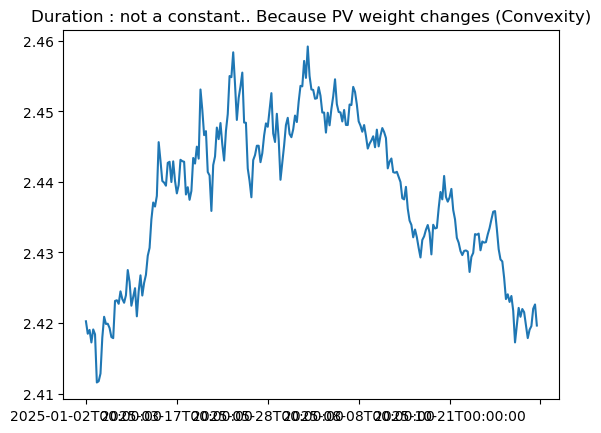

In [9]:
# duration is measure of T over PV space
terms = pd.Series(df_zero_rates.columns, index=df_zero_rates.columns)
bond_yield = df_zero_rates.iloc[:,-1]# YTM
cashflows = [3, 3, 3, 3, 3, 103]
discounts = np.exp( - pd.DataFrame(np.outer(bond_yield, terms), index = bond_yield.index, columns = terms.index))
duration = ( cashflows * terms * discounts ) .sum(axis=1) /  df_bond_price
duration.plot(title="Duration : not a constant.. Because PV weight changes (Convexity)")